# Clasificador

Exploracion del clasificador multiclase Manchester (C1-C5) sobre el dataset.

- Evaluacion out-of-fold con `cross_val_predict` (sin leakage train/test).
- Metricas clinicas: `f1_macro`, recall C1/C2, under-triage rate.
- Vocabulario cerrado desde `data/dictionaries/manchester_terms.csv`.
- Anti-leakage: `StratifiedGroupKFold` agrupando casos aumentados (`*_AUG_*`).
- `score_ansiedad` no entra como feature; la auditoria de sesgo vive en `audit-ethics`.


In [1]:
import io
import re
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from minio import Minio
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, recall_score
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
MANCHESTER_COLORS = {'C1': '#d62728', 'C2': '#ff7f0e', 'C3': '#f4d03f', 'C4': '#2ca02c', 'C5': '#1f77b4'}
CLASS_ORDER = ['C1', 'C2', 'C3', 'C4', 'C5']


## 1. Descargar el ultimo F1 desde minIO

In [2]:
client = Minio('localhost:9000', access_key='minio_admin', secret_key='minio_admin_pw', secure=False)
objs = [o for o in client.list_objects('datasets', recursive=True) if o.object_name.endswith('.parquet')]
objs.sort(key=lambda o: o.last_modified, reverse=True)
latest = objs[0]
print(f'usando {latest.object_name} ({latest.size} bytes) modified {latest.last_modified}')
obj = client.get_object('datasets', latest.object_name)
df = pd.read_parquet(io.BytesIO(obj.read()))
df.shape

usando triage_f1_20260527T083040-3a050d.parquet (1018971 bytes) modified 2026-05-27 08:30:40.049000+00:00


(284, 9)

## 2. EDA


In [3]:
df.head(10)


,guid,id_caso,origen,texto_original_en,resumen_es,entidades_extraidas_es,entidades_normalizadas_es,score_ansiedad,triage_real
0,seed-02,CAR0002,Dataset,NaN,se desmayo no responde paro respiratorio,"[se desmayo, no responde, paro respiratorio]",[sincope],0.05,C1
1,seed-06,RES0003,Dataset,NaN,disnea importante en reposo,[disnea importante en reposo],[disnea],0.10,C1
2,seed-01,CAR0001,Dataset,NaN,presion fuerte en el pecho con sudoracion fria,"[presion fuerte en el pecho, sudor]","[dolor_toracico_opresivo, sudoracion]",0.35,C1
3,71df4c17-f2ef-4ea7-a005-485e6b8ba4d0,CAR_AUG_001,MVP,NaN,Presion fuerte en el pecho irradiada al brazo ...,"[presion fuerte en el pecho, irradiada al braz...","[dolor_toracico_opresivo, sudoracion]",0.15,C1
4,aac84ea4-cfe4-482a-8520-422a2e1c9b25,CAR_AUG_002,MVP,NaN,"Doctor, presion fuerte en el pecho y me he des...","[presión fuerte en el pecho, desmayos]","[dolor_toracico_opresivo, sincope]",0.78,C1
5,d97cbb90-d5e0-4cac-9b2d-3ccf670ba8f8,CAR_AUG_003,MVP,NaN,presion fuerte en el pecho con sudoracion,"[presion fuerte en el pecho, sudoracion]","[dolor_toracico_opresivo, sudoracion]",0.30,C1
6,c476da8f-156f-49d5-a38f-9b91acbce7f1,CAR0004,Dataset,D: What brings you here today?\n\nP: I'm just ...,Paciente de 25 años sin antecedentes relevante...,"[dolor torácico agudo, dolor punzante, empeora...","[tos, dolor_toracico_agudo]",0.72,C3
7,661002af-35dc-4a6e-9c8a-e20007d1233f,CAR0005,Dataset,D: It sounds like that you're experiencing som...,"Paciente con dolor torácico agudo, localizado ...","[dolor torácico agudo, dolor torácico localiza...","[dolor_toracico_agudo, dolor_toracico_agudo]",0.80,C3
8,cf66e1e4-6668-4a07-9a63-9102533df39a,DER0001,Dataset,"P: Hey Doc, I'm a 45 year old man coming in, I...",Paciente masculino de 45 años con diabetes mal...,"[erupción dolorosa en tobillo derecho, edema, ...","[malestar, edema]",0.60,C4
9,8dd6f7c2-7a1a-4a40-b549-2f351583d0c0,GAS0003,Dataset,D: What brings you in here today? \n\nP: Yeah ...,Paciente con dolor abdominal en cuadrante supe...,[dolor abdominal en cuadrante superior derecho...,"[dolor_abdominal, nauseas]",0.10,C3


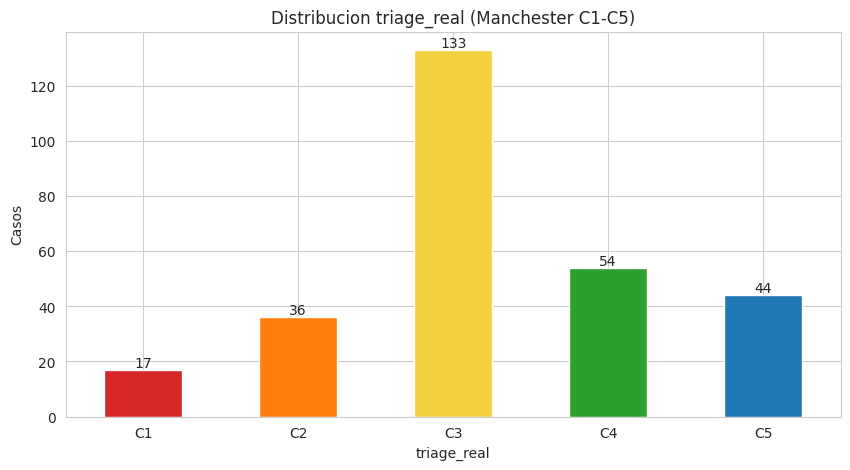

total: 284 | por clase: {'C1': 17, 'C2': 36, 'C3': 133, 'C4': 54, 'C5': 44}


In [4]:
dist = df['triage_real'].value_counts().reindex(CLASS_ORDER).fillna(0).astype(int)
ax = dist.plot(kind='bar', color=[MANCHESTER_COLORS[c] for c in dist.index])
for i, v in enumerate(dist.values):
    ax.text(i, v + 1, str(v), ha='center')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.title('Distribucion triage_real (Manchester C1-C5)')
plt.ylabel('Casos')
plt.show()
print('total:', len(df), '| por clase:', dist.to_dict())


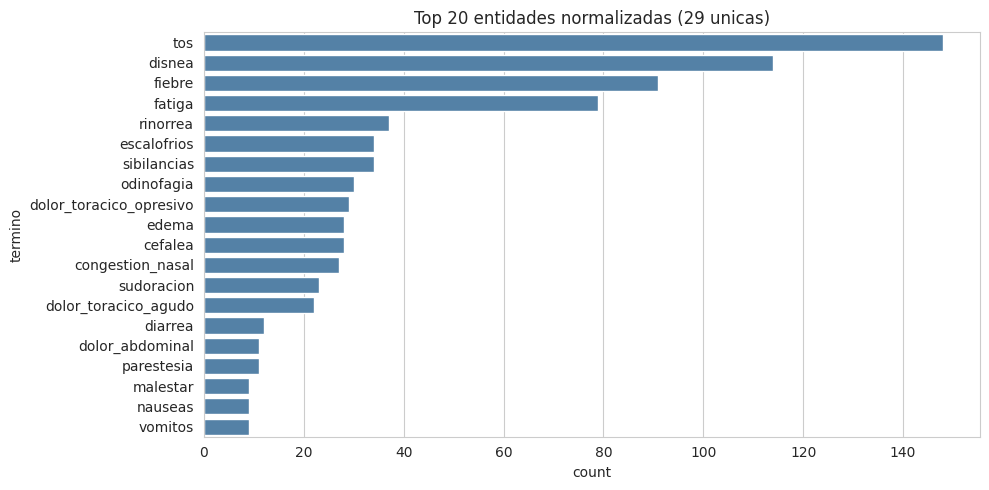

In [5]:
all_ents = []
for x in df['entidades_normalizadas_es']:
    if x is not None:
        all_ents.extend(list(x))
ent_counter = Counter(all_ents)
vocab_df = pd.DataFrame(ent_counter.most_common(20), columns=['termino', 'count'])
sns.barplot(data=vocab_df, x='count', y='termino', color='steelblue')
plt.title(f'Top 20 entidades normalizadas ({len(ent_counter)} unicas)')
plt.tight_layout()
plt.show()


## 3. Vocabulario cerrado desde el diccionario

El multi-hot de entidades se ajusta con los `termino_clinico` del diccionario Manchester, no con lo que aparezca en cada fold. Asi una entidad valida que solo este en el fold de validacion no se descarta.


In [6]:
DICT_PATH = Path('../data/dictionaries/manchester_terms.csv')
dict_df = pd.read_csv(DICT_PATH)
VOCAB = sorted(dict_df['termino_clinico'].dropna().unique().tolist())
print(f'{len(VOCAB)} terminos clinicos en el diccionario cerrado')

data_ents = set()
for x in df['entidades_normalizadas_es']:
    if x is not None:
        data_ents.update(list(x))
fuera = sorted(data_ents - set(VOCAB))
print('entidades en datos pero NO en diccionario (se ignoraran):', fuera)

30 terminos clinicos en el diccionario cerrado
entidades en datos pero NO en diccionario (se ignoraran): []


## 4. Features, target y grupos anti-leakage

`base_caso` agrupa los casos aumentados (`CAR_AUG_001`, ...) bajo un mismo grupo para que `StratifiedGroupKFold` no parta un caso y su augmentado en folds distintos.

Limitacion: sin un `parent_guid` emitido por `dataset-builder` el mapeo augmentado->semilla exacta no es perfecto; aqui agrupamos por el prefijo previo a `_AUG_`. Si en el futuro el F1 incluye el padre, usar esa columna.


In [7]:
feat_df = pd.DataFrame({
    'resumen_es': df['resumen_es'].fillna('').astype(str),
    'entidades_normalizadas_es': df['entidades_normalizadas_es'],
})
y = np.asarray(df['triage_real'])
groups = df['id_caso'].apply(lambda s: re.sub(r'_AUG_\d+$', '', str(s))).to_numpy()
print('filas:', len(y), '| grupos unicos:', len(set(groups)))
print('por clase:', dict(Counter(y)))

filas: 284 | grupos unicos: 273
por clase: {'C1': 17, 'C3': 133, 'C4': 54, 'C2': 36, 'C5': 44}


In [8]:
class MultiHotEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, vocab):
        self.vocab = vocab
    def fit(self, X, y=None):
        self.mlb_ = MultiLabelBinarizer(classes=self.vocab)
        self.mlb_.fit([[]])
        return self
    def transform(self, X):
        rows = [[e for e in (x if x is not None else []) if e in self.vocab] for x in X.iloc[:, 0]]
        return self.mlb_.transform(rows)
    def get_feature_names_out(self, input_features=None):
        return np.asarray(['ent_' + c for c in self.vocab])

def build_features():
    return ColumnTransformer([
        ('text', TfidfVectorizer(ngram_range=(1, 2), max_features=2000, min_df=1), 'resumen_es'),
        ('ent', MultiHotEncoder(VOCAB), ['entidades_normalizadas_es']),
    ])

## 5. Modelos y evaluacion out-of-fold

Todas las metricas se calculan sobre predicciones `cross_val_predict` (cada fila predicha por un modelo que no la vio). Comparamos `class_weight='balanced'` contra SMOTE.


In [9]:
LEVEL = {'C1': 1, 'C2': 2, 'C3': 3, 'C4': 4, 'C5': 5}
FINALISTS = ['logreg_balanced', 'random_forest_balanced', 'gradient_boosting']
FINALIST_LABELS = {
    'logreg_balanced': 'LogReg',
    'random_forest_balanced': 'Random Forest',
    'gradient_boosting': 'Grad. Boosting',
}
SELECTED_MODEL = 'logreg_balanced'

min_count = min(Counter(y).values())
n_splits = min(5, min_count)
cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)
k_neighbors = max(1, min(5, min_count - 2))
print(f'n_splits={n_splits} | min_count={min_count} | SMOTE k_neighbors={k_neighbors}')

def build_pipeline(clf, smote=False):
    steps = [('features', build_features())]
    if smote:
        steps.append(('smote', SMOTE(random_state=42, k_neighbors=k_neighbors)))
    steps.append(('clf', clf))
    return ImbPipeline(steps) if smote else Pipeline(steps)

models = {
    'logreg_balanced': build_pipeline(LogisticRegression(class_weight='balanced', max_iter=1000)),
    'logreg_smote': build_pipeline(LogisticRegression(max_iter=1000), smote=True),
    'random_forest_balanced': build_pipeline(RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=42)),
    'random_forest_smote': build_pipeline(RandomForestClassifier(n_estimators=200, random_state=42), smote=True),
    'gradient_boosting': build_pipeline(GradientBoostingClassifier(random_state=42)),
    'gradient_boosting_smote': build_pipeline(GradientBoostingClassifier(random_state=42), smote=True),
}


n_splits=5 | min_count=17 | SMOTE k_neighbors=5


In [10]:
def triage_metrics(y_true, y_pred):
    lvl_true = np.array([LEVEL[c] for c in y_true])
    lvl_pred = np.array([LEVEL[c] for c in y_pred])
    rec = dict(zip(CLASS_ORDER, recall_score(y_true, y_pred, labels=CLASS_ORDER, average=None, zero_division=0)))
    return {
        'f1_macro': f1_score(y_true, y_pred, average='macro'),
        'recall_C1': rec['C1'],
        'recall_C2': rec['C2'],
        'recall_C3': rec['C3'],
        'recall_C4': rec['C4'],
        'recall_C5': rec['C5'],
        'under_triage_rate': float(np.mean(lvl_pred > lvl_true)),
    }

METRIC_COLS = ['f1_macro', 'recall_C1', 'recall_C2', 'recall_C3', 'recall_C4', 'recall_C5', 'under_triage_rate']

results = {}
for name, pipe in models.items():
    oof = cross_val_predict(pipe, feat_df, y, cv=cv, groups=groups)
    results[name] = {
        'oof': oof,
        'cm': confusion_matrix(y, oof, labels=CLASS_ORDER),
        **triage_metrics(y, oof),
    }
    m = results[name]
    print(f"{name:26s} f1={m['f1_macro']:.3f}  C1={m['recall_C1']:.3f}  C2={m['recall_C2']:.3f}  C3={m['recall_C3']:.3f}  C4={m['recall_C4']:.3f}  C5={m['recall_C5']:.3f}  under={m['under_triage_rate']:.3f}")

summary = pd.DataFrame({
    name: {k: r[k] for k in METRIC_COLS}
    for name, r in results.items()
}).T

finalist_summary = summary.loc[FINALISTS].sort_values('f1_macro', ascending=False)
winner = SELECTED_MODEL
print(f'modelo en produccion (ml-training): {FINALIST_LABELS[winner]}')
print(f'criterio de seleccion: f1_macro entre candidatos con class_weight')
finalist_summary


logreg_balanced            f1=0.698  C1=0.471  C2=0.667  C3=0.767  C4=0.796  C5=0.795  under=0.137
logreg_smote               f1=0.712  C1=0.471  C2=0.639  C3=0.805  C4=0.778  C5=0.818  under=0.144
random_forest_balanced     f1=0.613  C1=0.824  C2=0.167  C3=0.962  C4=0.648  C5=0.318  under=0.137
random_forest_smote        f1=0.662  C1=0.824  C2=0.306  C3=0.947  C4=0.685  C5=0.386  under=0.123
gradient_boosting          f1=0.609  C1=0.471  C2=0.361  C3=0.827  C4=0.648  C5=0.591  under=0.180
gradient_boosting_smote    f1=0.610  C1=0.412  C2=0.444  C3=0.827  C4=0.611  C5=0.636  under=0.173
modelo en produccion (ml-training): LogReg
criterio de seleccion: f1_macro entre candidatos con class_weight


,f1_macro,recall_C1,recall_C2,recall_C3,recall_C4,recall_C5,under_triage_rate
logreg_balanced,0.697864,0.470588,0.666667,0.766917,0.796296,0.795455,0.137324
random_forest_balanced,0.613367,0.823529,0.166667,0.962406,0.648148,0.318182,0.137324
gradient_boosting,0.608933,0.470588,0.361111,0.827068,0.648148,0.590909,0.179577


## 6. Comparacion de los modelos


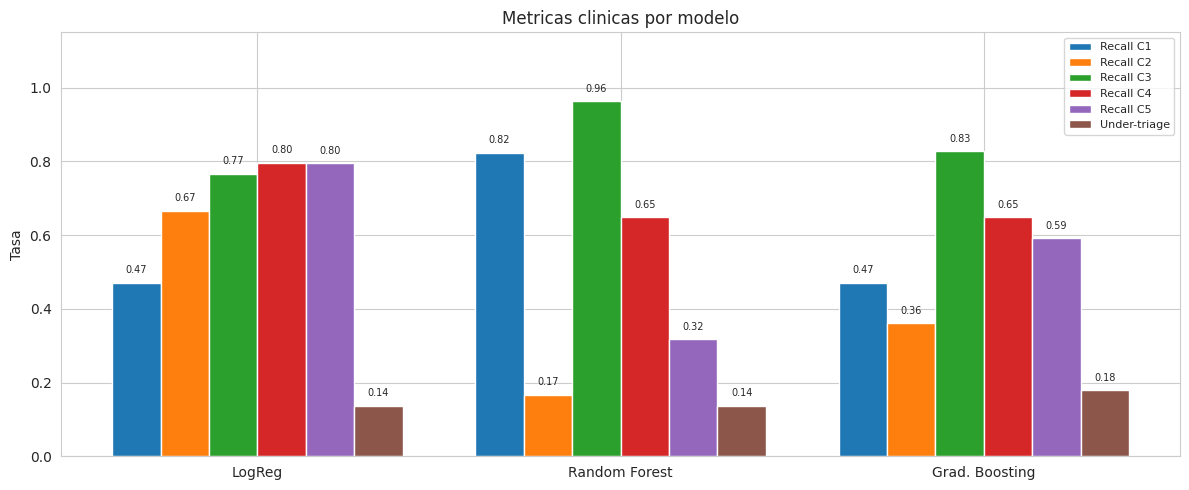

In [14]:
plot_df = finalist_summary[['recall_C1', 'recall_C2', 'recall_C3', 'recall_C4', 'recall_C5', 'under_triage_rate']].copy()
plot_df.index = [FINALIST_LABELS[i] for i in plot_df.index]
plot_df.columns = ['Recall C1', 'Recall C2', 'Recall C3', 'Recall C4', 'Recall C5', 'Under-triage']

x = np.arange(len(plot_df))
n_cols = len(plot_df.columns)
width = 0.8 / n_cols
fig, ax = plt.subplots(figsize=(12, 5))
for i, col in enumerate(plot_df.columns):
    offset = (i - n_cols / 2 + 0.5) * width
    bars = ax.bar(x + offset, plot_df[col].values, width, label=col)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.02, f'{h:.2f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Tasa')
ax.set_title('Metricas clinicas por modelo')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()


## 7. Matriz de confusion del modelo

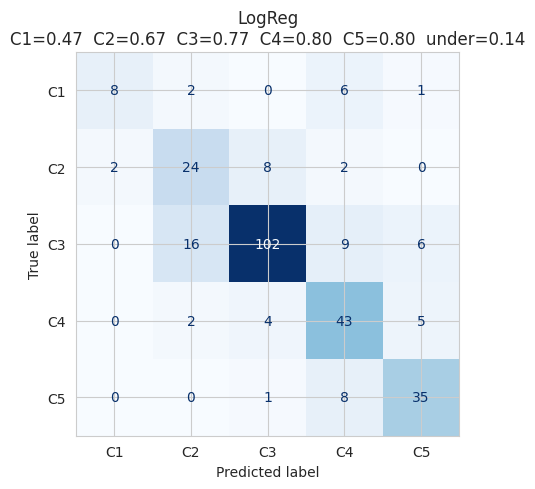

In [12]:
r = results[winner]
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=r['cm'], display_labels=CLASS_ORDER)
disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
ax.set_title(f'{FINALIST_LABELS.get(winner, winner)}\n'
             f'C1={r["recall_C1"]:.2f}  C2={r["recall_C2"]:.2f}  C3={r["recall_C3"]:.2f}  '
             f'C4={r["recall_C4"]:.2f}  C5={r["recall_C5"]:.2f}  under={r["under_triage_rate"]:.2f}')
plt.tight_layout()
plt.show()


## 8. SMOTE vs class_weight

Comparacion rapida con variantes SMOTE. Decision del proyecto: `class_weight` por dataset pequeno y features dispersas.


In [13]:
smote_compare = summary.loc[['logreg_balanced', 'logreg_smote', 'random_forest_balanced', 'random_forest_smote']]
smote_compare[METRIC_COLS].round(3)


,f1_macro,recall_C1,recall_C2,recall_C3,recall_C4,recall_C5,under_triage_rate
logreg_balanced,0.698,0.471,0.667,0.767,0.796,0.795,0.137
logreg_smote,0.712,0.471,0.639,0.805,0.778,0.818,0.144
random_forest_balanced,0.613,0.824,0.167,0.962,0.648,0.318,0.137
random_forest_smote,0.662,0.824,0.306,0.947,0.685,0.386,0.123
